# Examine version 3 of the catalog with amplitudes 

This notebook is used to check whether the amplitude information is correctly added to version 3 of the pick assignment table. 

By Hiroto Bito

In [15]:
import os
import sys
import pandas as pd
import numpy as np

from obspy.core import UTCDateTime
import time
from obspy.core.stream import Stream
import matplotlib.pyplot as plt


parent_dir = '/home/hbito/cascadia_obs_ensemble/utils'
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

from data_client import get_waveforms

In [16]:
datasets_dir =  '/wd1/hbito_data/data/datasets_all_regions'
path_assigned_picks_df = f'{datasets_dir}/Cascadia_updated_catalog_picks_assignment_ver_3_w_amp_test.csv'
assigned_picks_df = pd.read_csv(path_assigned_picks_df, index_col=False)

In [17]:
skipped_csv_path = f'{datasets_dir}/calculate_amplitudes_skipped_picks_test.csv'
skipped_picks_df = pd.read_csv(skipped_csv_path)

In [18]:
dir_plots = datasets_dir+'/plot_examine_amp_calculation'
os.makedirs(name=dir_plots, exist_ok=True)

In [19]:
# Print the number of rows of assigned_picks_df and the first 10 rows
print("Number of rows: ", len(assigned_picks_df))
assigned_picks_df.head(10)

Number of rows:  1004335


,Unnamed: 0,time_pick,station,phase,timeres,idx,arid,latitude,longitude,depth,Detection Value,time,RMS Residual (s),Num. P,Num. S,picks,slatitude,slongitude,selevation,Amplitude
0,0,2010-01-01T00:15:27.180000Z,UW.PCMD,P,0.049,0,0,47.13396,-122.09098,60.147,0.68,2010-01-01 00:15:16.204000+00:00,1.081,2,5,7,46.888962,-122.301483,239.0,534.658499
1,1,2010-01-01T00:15:37.840400Z,UW.RVW,P,1.264,0,1,47.13396,-122.09098,60.147,0.68,2010-01-01 00:15:16.204000+00:00,1.081,2,5,7,46.149750,-122.742996,504.0,73.403575
2,2,2010-01-01T00:15:33.280000Z,UW.PCMD,S,-0.243,0,2,47.13396,-122.09098,60.147,0.68,2010-01-01 00:15:16.204000+00:00,1.081,2,5,7,46.888962,-122.301483,239.0,897.182138
3,3,2010-01-01T00:15:42.002000Z,UW.GNW,S,2.402,0,3,47.13396,-122.09098,60.147,0.68,2010-01-01 00:15:16.204000+00:00,1.081,2,5,7,47.564130,-122.824980,220.0,2239.571065
4,4,2010-01-01T00:15:43.618400Z,PB.B013,S,-0.651,0,4,47.13396,-122.09098,60.147,0.68,2010-01-01 00:15:16.204000+00:00,1.081,2,5,7,47.813000,-122.910797,75.3,60.932284
5,5,2010-01-01T00:15:43.768400Z,PB.B943,S,-0.511,0,5,47.13396,-122.09098,60.147,0.68,2010-01-01 00:15:16.204000+00:00,1.081,2,5,7,47.813202,-122.911301,84.2,45.608438
6,6,2010-01-01T00:15:48.060400Z,UW.BOW,S,-0.263,0,6,47.13396,-122.09098,60.147,0.68,2010-01-01 00:15:16.204000+00:00,1.081,2,5,7,46.474831,-123.229301,870.0,26.518675
7,7,2010-01-01T00:17:04.730000Z,UW.PASS,P,-0.499,1,7,48.17742,-121.83289,6.163,0.84,2010-01-01 00:16:49.343000+00:00,0.985,25,30,55,48.998299,-122.085197,175.4,240.412236
8,8,2010-01-01T00:17:05.008400Z,PB.B943,P,-0.252,1,8,48.17742,-121.83289,6.163,0.84,2010-01-01 00:16:49.343000+00:00,0.985,25,30,55,47.813202,-122.911301,84.2,46.170710
9,9,2010-01-01T00:17:05.020400Z,UW.BLN,P,0.415,1,9,48.17742,-121.83289,6.163,0.84,2010-01-01 00:16:49.343000+00:00,0.985,25,30,55,48.006624,-122.972646,601.0,94.172872


In [20]:
# Print the number of rows of assigned_picks_df and the first 10 rows
print("Number of rows: ", len(skipped_picks_df))
skipped_picks_df.head(10)

Number of rows:  36391


,network,station,channel,origin_time,time_pick,starttime,endtime,reason
0,UW,VVHS,*H*,2010-04-16T22:48:21.535000Z,2010-04-16T22:48:24.980000Z,2010-04-16T22:48:24.480000Z,2010-04-16T22:48:26.980000Z,Request failed: No Vertical Component Data Pre...
1,CN,HNB,*H*,2010-04-28T14:36:42.921000Z,2010-04-28T14:36:53.940000Z,2010-04-28T14:36:53.440000Z,2010-04-28T14:36:55.940000Z,Request failed: No Vertical Component Data Pre...
2,UW,SP2,*H*,2010-04-30T16:01:16.639000Z,2010-04-30T16:01:35.360000Z,2010-04-30T16:01:34.860000Z,2010-04-30T16:01:37.360000Z,Request failed: No Vertical Component Data Pre...
3,UW,SP2,*H*,2010-04-30T20:11:55.912000Z,2010-04-30T20:12:05.360000Z,2010-04-30T20:12:04.860000Z,2010-04-30T20:12:07.360000Z,Request failed: No Vertical Component Data Pre...
4,UW,SP2,*H*,2010-05-01T04:18:47.446000Z,2010-05-01T04:18:57.850000Z,2010-05-01T04:18:57.350000Z,2010-05-01T04:18:59.850000Z,Request failed: No Vertical Component Data Pre...
5,UW,SP2,*H*,2010-06-22T15:49:24.169000Z,2010-06-22T15:49:37.870000Z,2010-06-22T15:49:37.370000Z,2010-06-22T15:49:39.870000Z,Request failed: No Vertical Component Data Pre...
6,UW,SP2,*H*,2010-06-23T01:10:53.872000Z,2010-06-23T01:11:05.360000Z,2010-06-23T01:11:04.860000Z,2010-06-23T01:11:07.360000Z,Request failed: No Vertical Component Data Pre...
7,UW,SP2,*H*,2010-06-24T09:46:51.644000Z,2010-06-24T09:47:05.420000Z,2010-06-24T09:47:04.920000Z,2010-06-24T09:47:07.420000Z,Request failed: No Vertical Component Data Pre...
8,UW,SP2,*H*,2010-06-27T23:17:12.133000Z,2010-06-27T23:17:27.920000Z,2010-06-27T23:17:27.420000Z,2010-06-27T23:17:29.920000Z,Request failed: No Vertical Component Data Pre...
9,UW,SP2,*H*,2010-07-31T04:04:17.592000Z,2010-07-31T04:05:02.760000Z,2010-07-31T04:05:02.260000Z,2010-07-31T04:05:04.760000Z,Request failed: No Vertical Component Data Pre...


### Make plots to make sure that the amplitude calculation was correct

test

In [33]:
assigned_picks_df.iloc[0]['time_pick']

'2010-01-01T00:15:27.180000Z'

endtest

In [ ]:
# Function to plot waveforms using Obspy bulk request
 
def plot_waveforms_for_picks(assigned_picks_df, dir_plots, window_before=30, window_after=120, window_amp_calc_before = 0.5, window_amp_calc_after = 2, n_picks=100, source='pnwstore', scaling_factor_vline=0.1):
     
    # Prepare the lists
    bulk = []
    pick_info = []
    # ls_idx = np.random.choice(a=len(assigned_picks_df), size=(n_picks))
    ls_idx = np.arange(n_picks)
    
    # for i, row in assigned_picks_df.head(n_picks).iterrows():
    for i in range(len(ls_idx)):
        orid = assigned_picks_df.iloc[ls_idx[i]]['idx']
        pick_id = assigned_picks_df.iloc[ls_idx[i]]['arid']
      
        date, _time = assigned_picks_df.iloc[ls_idx[i]]['time'].split(' ')
        datetime_str = date+'T'+_time
        origin_time = UTCDateTime(datetime_str)  # Accept ISO string directly
        latitude = assigned_picks_df.iloc[ls_idx[i]]['latitude']
        longitude = assigned_picks_df.iloc[ls_idx[i]]['longitude']
        depth = assigned_picks_df.iloc[ls_idx[i]]['depth']
        
        # You may need to adjust these fields to match your DataFrame columns
        network = assigned_picks_df.iloc[ls_idx[i]]['station'].split('.')[0].strip()
        station = assigned_picks_df.iloc[ls_idx[i]]['station'].split('.')[1].strip()
        channel = "*H*"
        starttime = origin_time - window_before 
        endtime = origin_time + window_after
        time_pick = UTCDateTime(assigned_picks_df.iloc[ls_idx[i]]['time_pick'])
        time_pick_origin  = UTCDateTime(assigned_picks_df.iloc[ls_idx[i]]['time_pick']) - origin_time
        phase = assigned_picks_df.iloc[ls_idx[i]]['phase']
        amp = assigned_picks_df.iloc[ls_idx[i]]['Amplitude']

        bulk.append((network, station, channel, starttime, endtime))
        pick_info.append({
            'orid': orid,
            'pick_id': pick_id,
            'origin_time': origin_time,
            'latitude': latitude,
            'longitude': longitude,
            'depth': depth,
            'network': network,
            'station': station,
            'channel': channel,
            'starttime': starttime,
            'endtime': endtime,
            'time_pick': time_pick,
            'time_pick_origin': time_pick_origin,
            'phase': phase,
            'amp': amp
        })


    # Parameters to process waveforms
    new_sampling_rate = 100 # in Hz
    # freqmax = 15 # in Hz
    # freqmin = 4 # in Hz
    freq_highpass = 2 # in Hz


    # Plotting
    for i, info in enumerate(pick_info):

        network = pick_info[i]['network']
        station = pick_info[i]['station']
        channel = pick_info[i]['channel']
        starttime = pick_info[i]['starttime']
        endtime = pick_info[i]['endtime']
        amp = pick_info[i]['amp']

        time_pick = pick_info[i]['time_pick']
        time_pick_origin = pick_info[i]['time_pick_origin']

        fname = dir_plots+f"/{network}_{station}_arid_{info['pick_id']}.png"

        time.sleep(0.1)

        try:
            st = get_waveforms(
                network=network,
                station=station,
                channel=channel,
                starttime=starttime,
                endtime=endtime,
                source=source
            )
        except Exception as e:
            print(f"Request failed: {e}")
            st = Stream()

        time.sleep(0.1)

        # ---------------------------------------------------------
        # Select preferred channel family
        # ---------------------------------------------------------

        has_HH = bool(st.select(id=f'{network}.{station}..HH?'))
        has_BH = bool(st.select(id=f'{network}.{station}..BH?'))
        has_EH = bool(st.select(id=f'{network}.{station}..EH?'))

        sdata = Stream()

        if has_HH:
            sdata += st.select(id=f'{network}.{station}..HH*')
            channel_prefix = "HH"

        elif has_BH:
            sdata += st.select(id=f'{network}.{station}..BH*')
            channel_prefix = "BH"

        elif has_EH:
            sdata += st.select(id=f'{network}.{station}..EH*')
            channel_prefix = "EH"

        else:
            print(f'No HH, BH, or EH data available at {network}.{station} at {time_pick}. Skipping.')
            continue

        # ---------------------------------------------------------
        # Create figure with 3 components
        # ---------------------------------------------------------

        fig, axes = plt.subplots(
            3,
            1,
            figsize=(12, 8),
            sharex=True
        )

        component_list = ['Z', 'N', 'E']

        for ax, comp in zip(axes, component_list):

            tr_select = sdata.select(channel=f"{channel_prefix}{comp}")

            # -----------------------------------------------------
            # Leave blank if component does not exist
            # -----------------------------------------------------

            if len(tr_select) == 0:

                ax.set_title(f"{channel_prefix}{comp} : No Data")
                ax.grid()

                continue

            tr = tr_select[0].copy()

            # -----------------------------------------------------
            # Process waveform
            # -----------------------------------------------------

            tr.resample(new_sampling_rate)

            tr.detrend(type='demean')
            tr.taper(max_percentage=0.05)
            tr.filter(type='highpass', freq=freq_highpass)

            data = tr.data

            times = np.linspace(
                -window_before,
                window_after,
                tr.stats.npts
            )

            time_vline = time_pick_origin

            ymax = np.max(np.abs(data)) * scaling_factor_vline
            ymin = -np.max(np.abs(data)) * scaling_factor_vline

            xmax = time_vline + window_amp_calc_after
            xmin = time_vline - window_amp_calc_before

            # -----------------------------------------------------
            # Plot waveform
            # -----------------------------------------------------

            ax.axvspan(
                xmin,
                xmax,
                color='b',
                alpha=0.2
            )

            ax.plot(times, data)

            ax.vlines(
                time_vline,
                ymin,
                ymax,
                color='k',
                linestyles='solid'
            )

            ax.hlines(
                amp,
                xmax=xmax,
                xmin=xmin,
                color='r'
            )

            ax.hlines(
                -amp,
                xmax=xmax,
                xmin=xmin,
                color='r'
            )

            ax.set_ylabel(comp)
            ax.grid()

        # ---------------------------------------------------------
        # Common formatting
        # ---------------------------------------------------------

        axes[0].set_title(
            f"Origin ID: {info['orid']} | "
            f"Pick ID: {info['pick_id']} | "
            f"Network: {info['network']} | "
            f"Station: {info['station']} | "
            f"Channel: {channel_prefix} | "
            f"Phase: {info['phase']}"
        )

        axes[-1].set_xlabel("Time (s) from Origin Time")

        ticks = np.arange(-window_before, window_after, 10)
        str_ticks = [str(t) for t in ticks]

        axes[-1].set_xticks(ticks=ticks, labels=str_ticks)

        # Event information box
        info_text = (
            f"Origin Time: {info['origin_time']}\n"
            f"Latitude: {info['latitude']}\n"
            f"Longitude: {info['longitude']}\n"
            f"Depth: {info['depth']}\n"
            f"Amplitude: {np.round(amp, decimals=1)}"
        )

        props = dict(
            boxstyle='round',
            facecolor='wheat',
            alpha=0.5
        )

        axes[0].text(
            0.98,
            0.98,
            info_text,
            transform=axes[0].transAxes,
            fontsize=10,
            verticalalignment='top',
            horizontalalignment='right',
            bbox=props
        )

        plt.tight_layout()
        plt.show()
        plt.savefig(fname=fname, format='png')
        plt.close(fig)

        time.sleep(0.1)



test

In [29]:
np.round(assigned_picks_df.iloc[0]['Amplitude'], decimals=1)

534.7

end test

In [30]:
# Define the variables in the function
idx = np.random.choice(a=len(assigned_picks_df), size=20)
df = assigned_picks_df.iloc[idx]
window_before = 30 # in sec
window_after = 150 # in sec
window_amp_calc_before = 0.5 # in sec
window_amp_calc_after = 2 # in sec
n_picks = 20
source = 'pnwstore'
scaling_factor_vline = 0.3

In [31]:
df

,Unnamed: 0,time_pick,station,phase,timeres,idx,arid,latitude,longitude,depth,Detection Value,time,RMS Residual (s),Num. P,Num. S,picks,slatitude,slongitude,selevation,Amplitude
250511,250511,2012-01-04T12:27:53.918400Z,PB.B011,P,0.006,17787,250511,48.62703,-123.01586,13.4280,0.778,2012-01-04 12:27:48.808000+00:00,0.811,10,14,24,48.649544,-123.448189,22.0,142.878383
991985,991985,2015-06-04T08:25:57.082000Z,7D.FS06D,S,0.164,63152,991985,40.53859,-124.82371,18.5575,0.803,2015-06-04 08:25:47.861000+00:00,0.435,9,16,25,40.369999,-124.806702,-1946.8,2288.340124
70156,70156,2010-07-28T00:44:53.218400Z,PB.B203,S,-0.021,5045,70156,46.02905,-122.67973,19.2190,0.669,2010-07-28 00:44:42.816000+00:00,0.082,5,7,12,46.168999,-122.333664,814.4,39.907341
760938,760938,2014-08-12T17:22:51.480473Z,UW.TDL,P,0.200,49593,760938,46.68630,-122.69443,20.9570,0.660,2014-08-12 17:22:40.909000+00:00,0.419,3,8,11,46.350670,-122.217040,1400.0,91.093875
774414,774414,2014-08-28T01:13:13.520000Z,NC.KCT,S,0.645,50412,774414,40.69135,-124.84435,17.4990,0.754,2014-08-28 01:12:56.590000+00:00,0.651,9,9,18,40.475567,-124.337486,378.0,376.992702
727565,727565,2014-06-23T17:08:39.880000Z,NC.KMR,S,0.506,47422,727565,40.32933,-124.46345,13.9235,0.830,2014-06-23 17:08:18.431000+00:00,0.726,7,6,13,40.202175,-123.708633,915.0,475.685519
253234,253234,2012-01-11T04:09:59.128400Z,PB.B045,P,-0.440,17955,253234,40.42171,-124.32228,22.5930,0.786,2012-01-11 04:09:52.874000+00:00,0.807,34,28,62,40.436001,-123.996498,29.4,11821.155239
788918,788918,2014-09-16T15:22:26.788400Z,PB.B201,S,0.095,51284,788918,47.51163,-121.75036,9.4890,0.760,2014-09-16 15:21:46.525000+00:00,1.158,29,29,58,46.303299,-122.264801,990.0,173.388535
301629,301629,2012-04-17T06:15:23.846200Z,7D.J44A,P,-0.994,20770,301629,43.02814,-126.76979,16.9635,0.737,2012-04-17 06:14:37.631000+00:00,1.029,55,30,85,46.323002,-127.039001,-2724.1,7635.078774
768984,768984,2014-08-20T23:24:37.698500Z,7D.G20D,P,-1.078,50067,768984,40.57210,-127.05920,0.7230,0.970,2014-08-20 23:24:25.529000+00:00,1.070,33,25,58,41.451599,-126.863800,-2931.3,3353.210613


PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


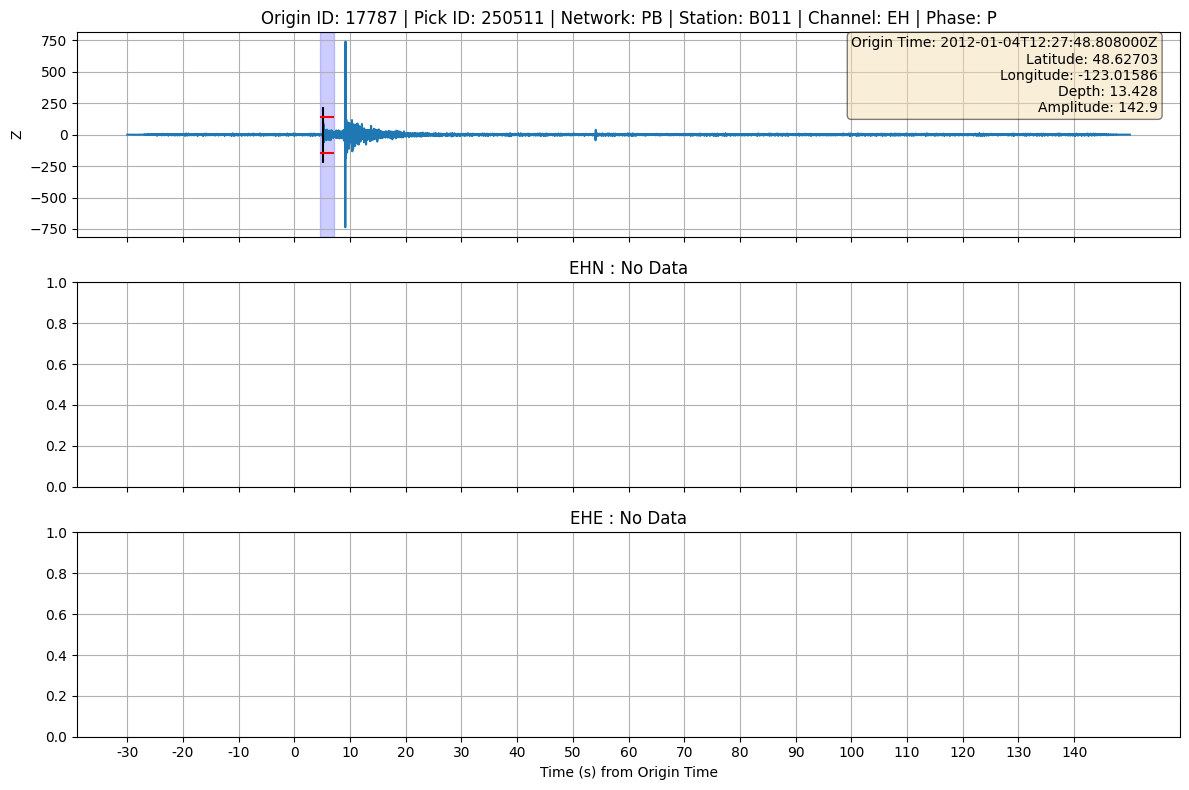

PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


<Figure size 640x480 with 0 Axes>

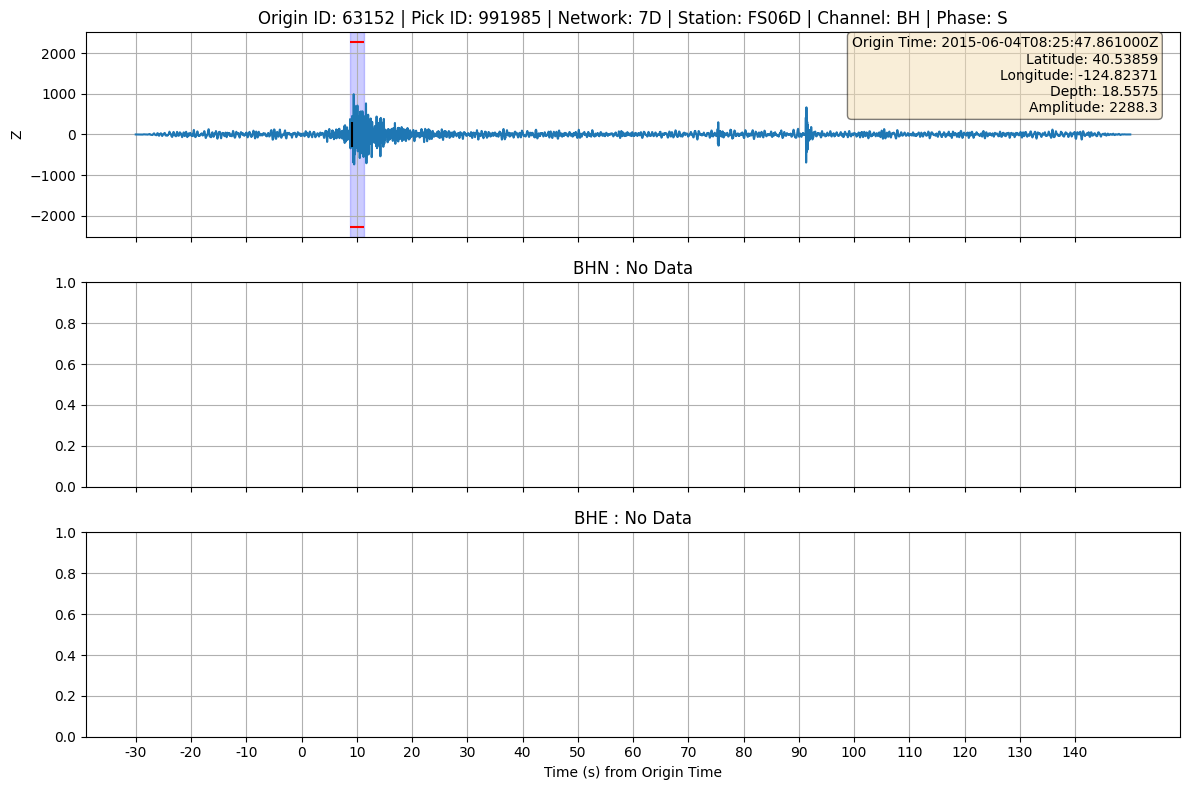

PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


<Figure size 640x480 with 0 Axes>

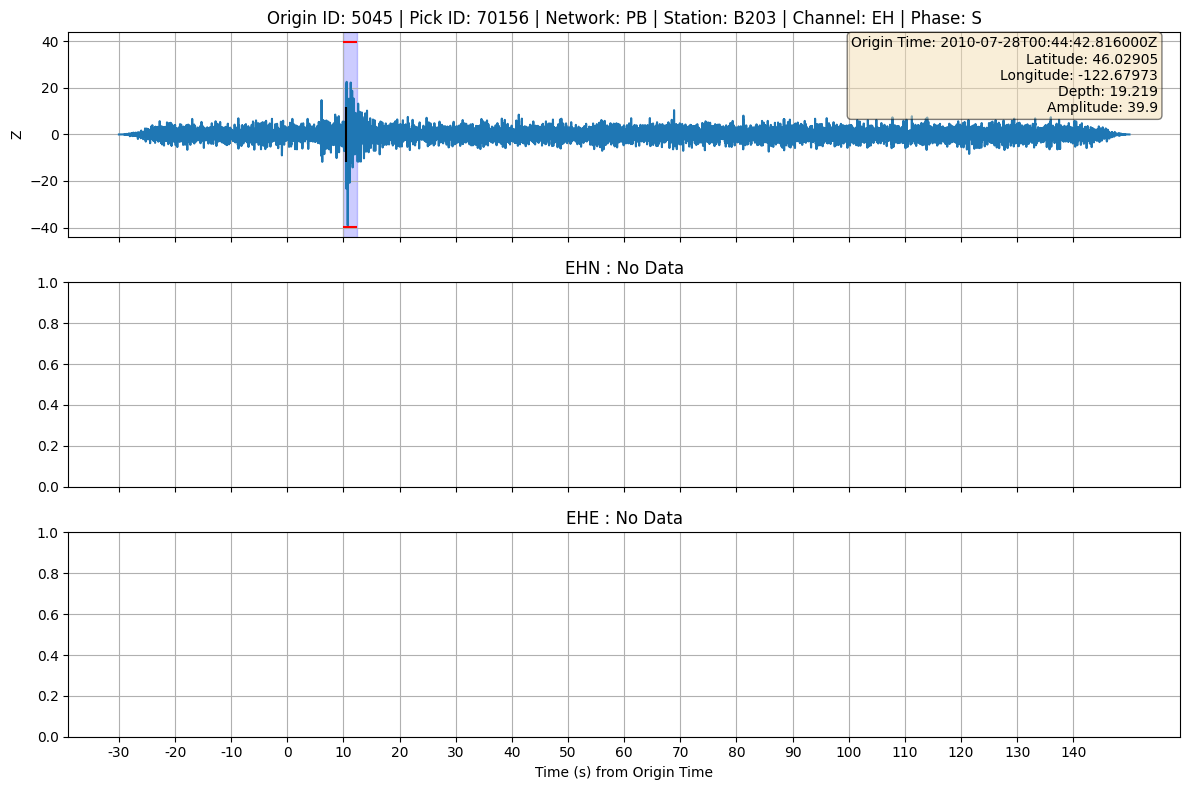

PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


<Figure size 640x480 with 0 Axes>

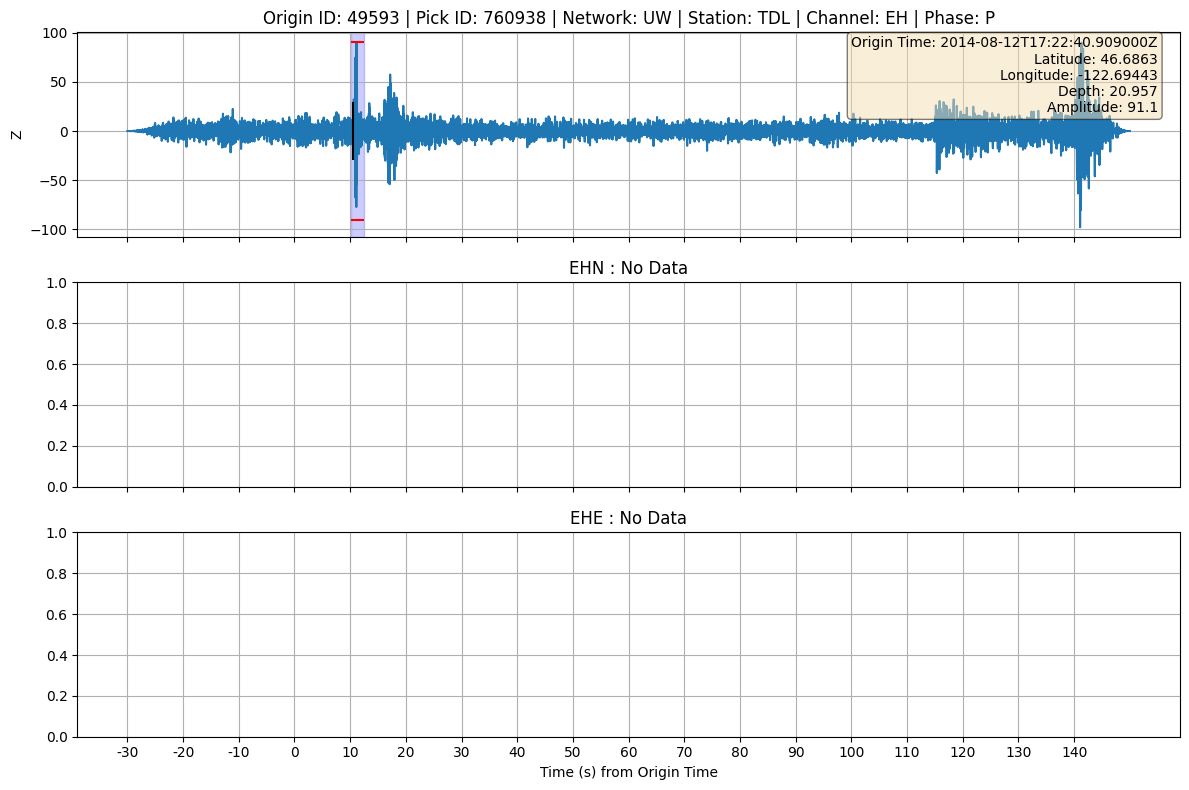

<Figure size 640x480 with 0 Axes>

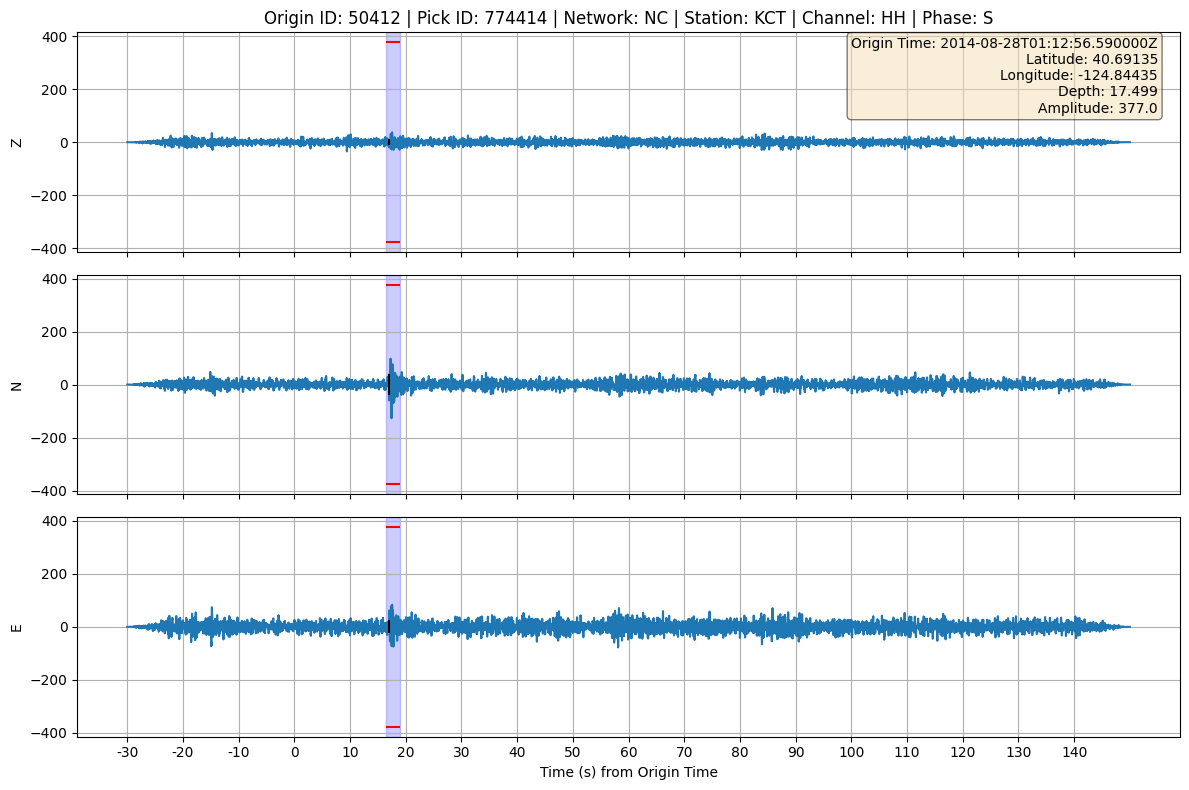

<Figure size 640x480 with 0 Axes>

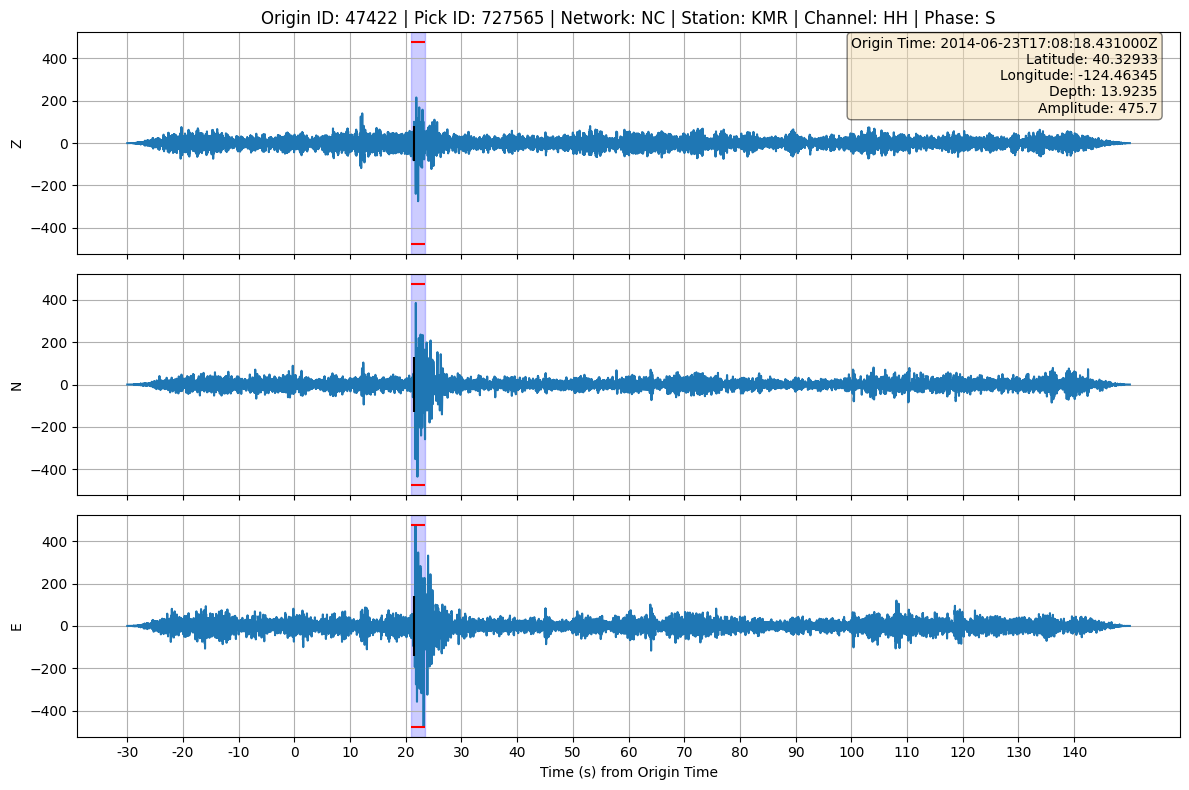

PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


<Figure size 640x480 with 0 Axes>

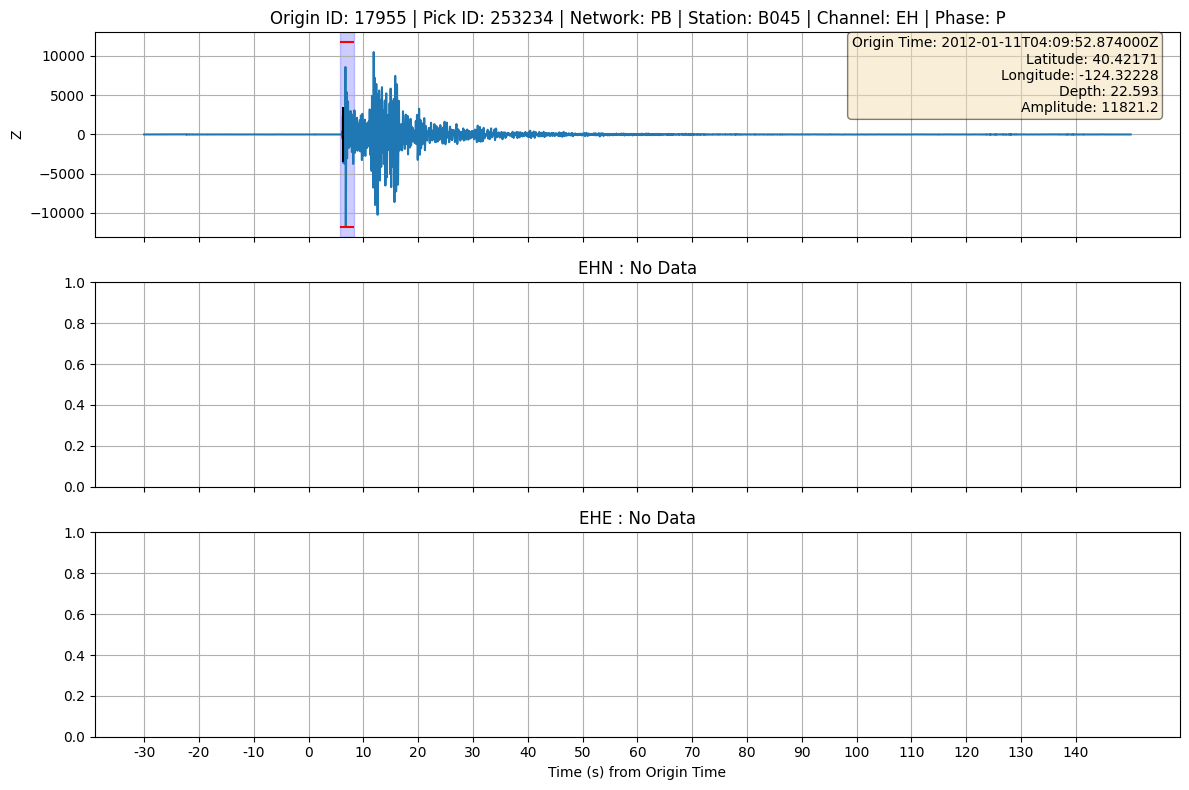

PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


<Figure size 640x480 with 0 Axes>

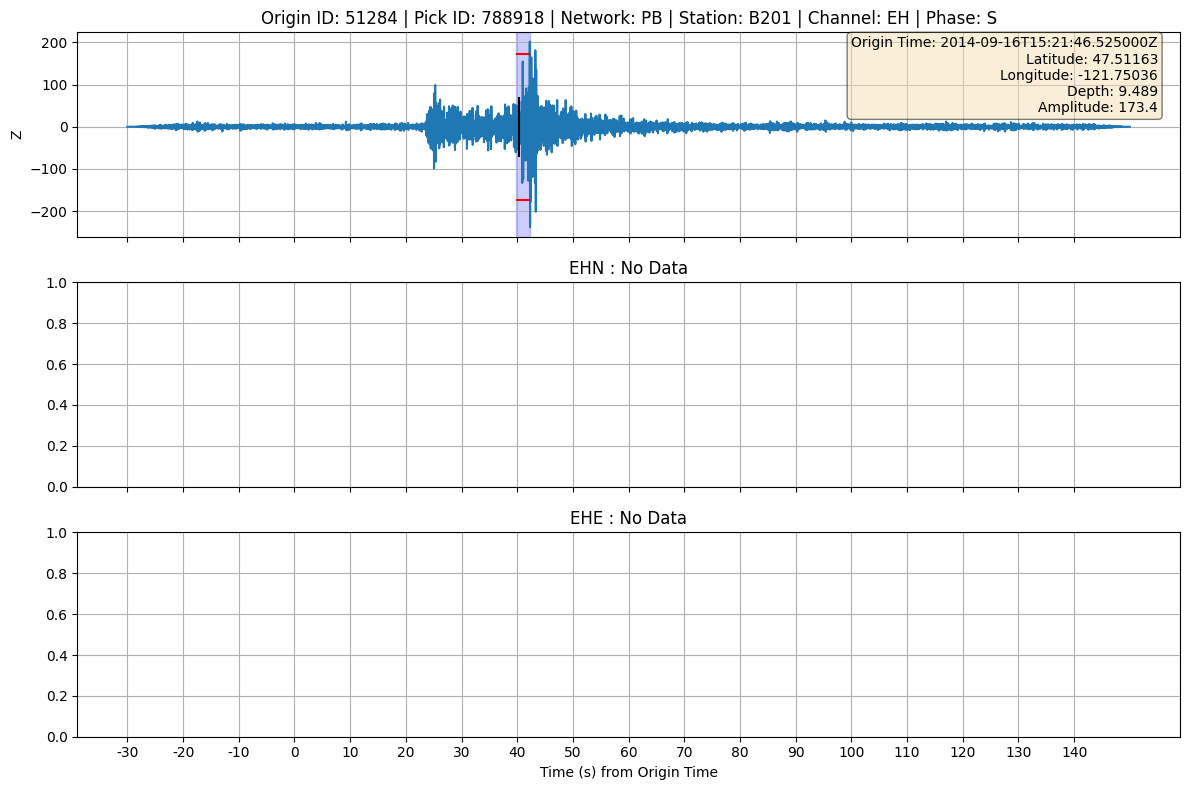

PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


<Figure size 640x480 with 0 Axes>

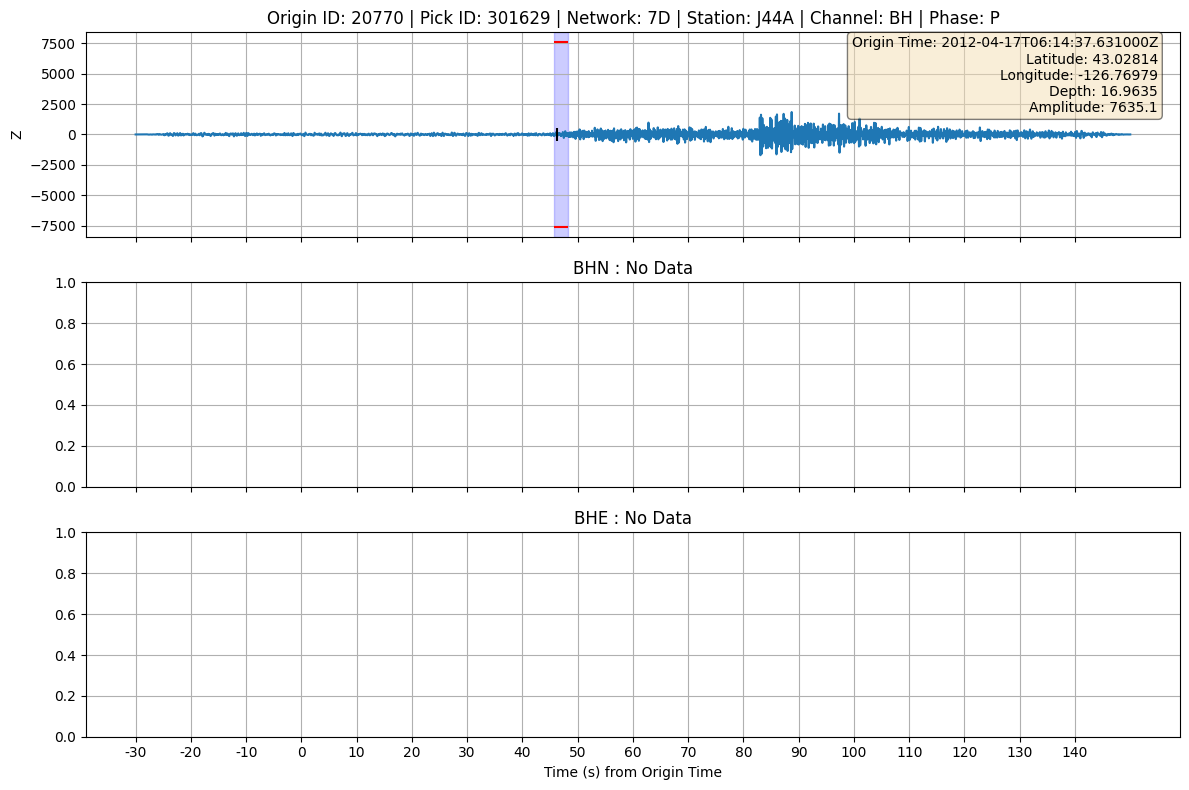

PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


<Figure size 640x480 with 0 Axes>

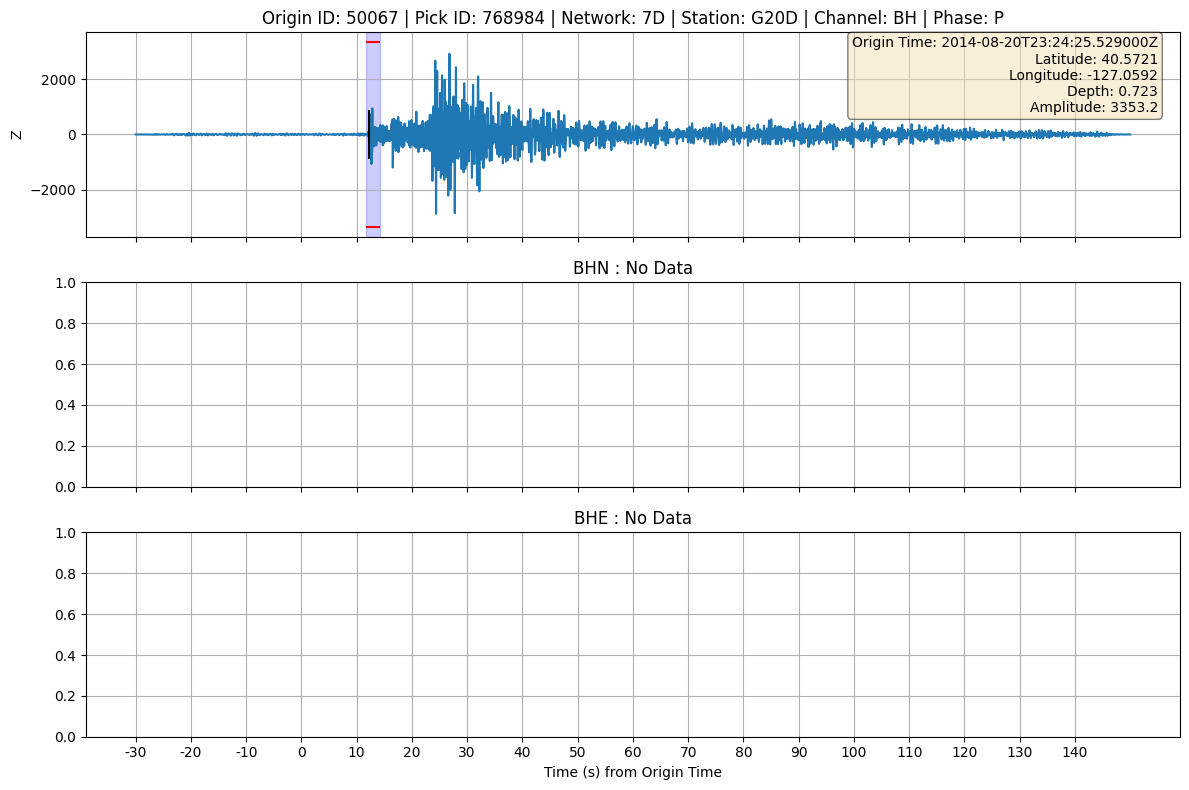

PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


<Figure size 640x480 with 0 Axes>

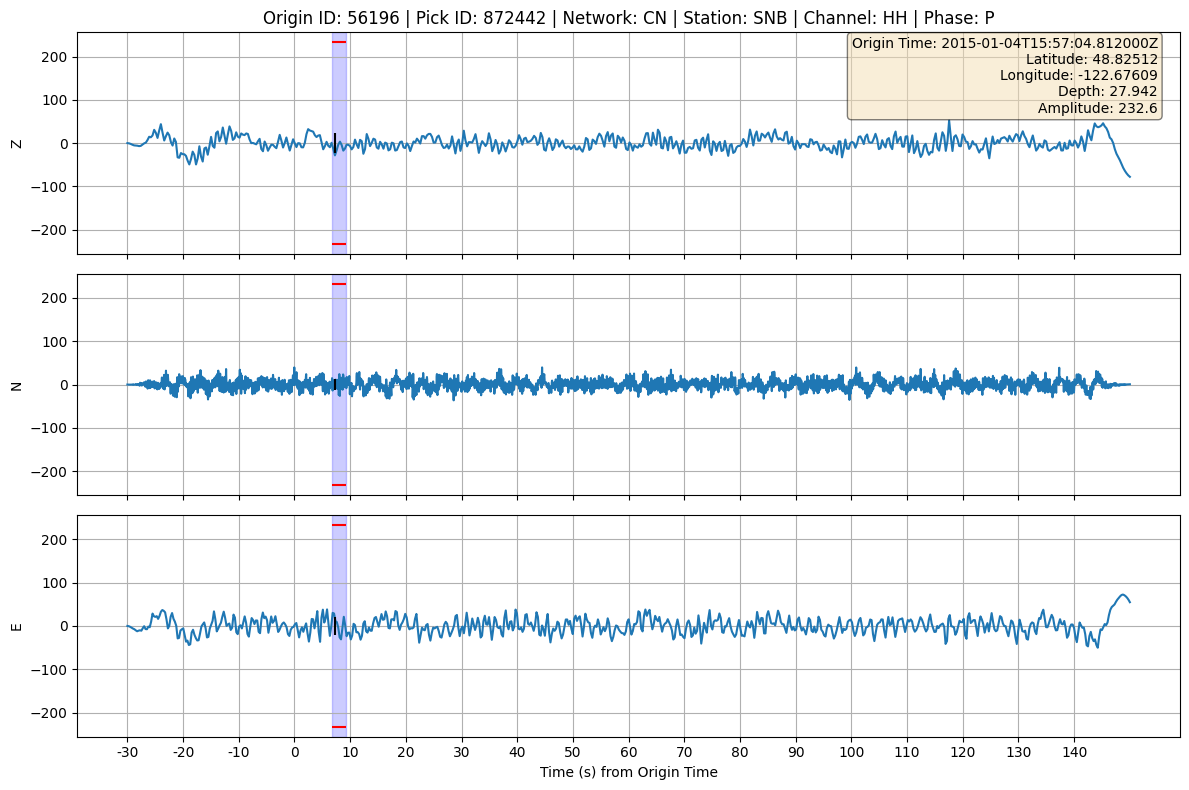

PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


<Figure size 640x480 with 0 Axes>

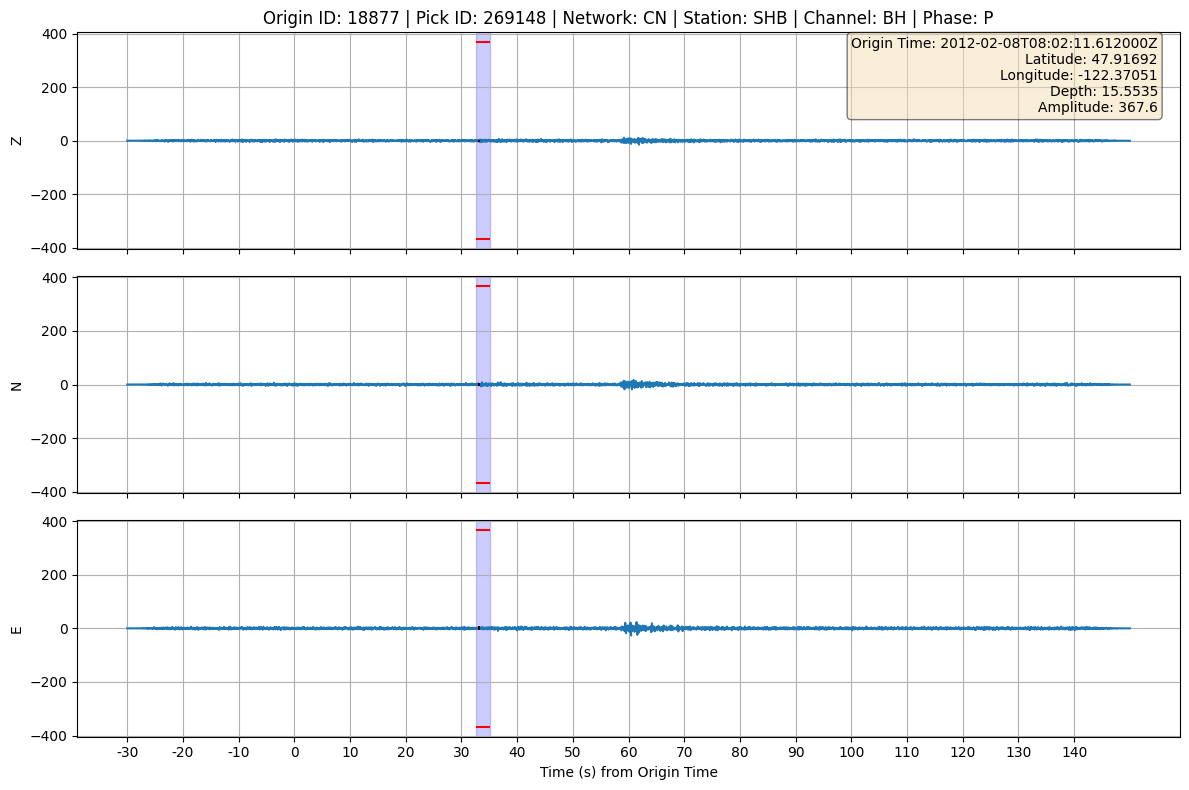

PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


<Figure size 640x480 with 0 Axes>

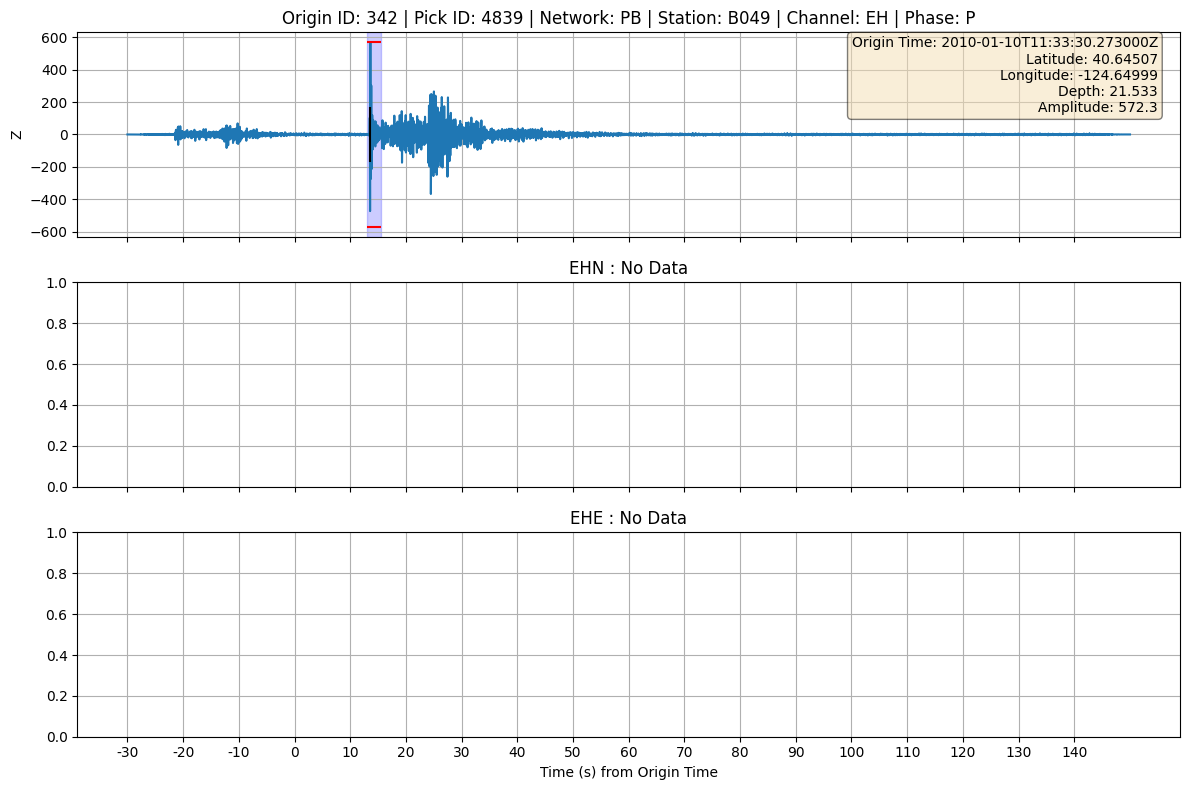

PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


<Figure size 640x480 with 0 Axes>

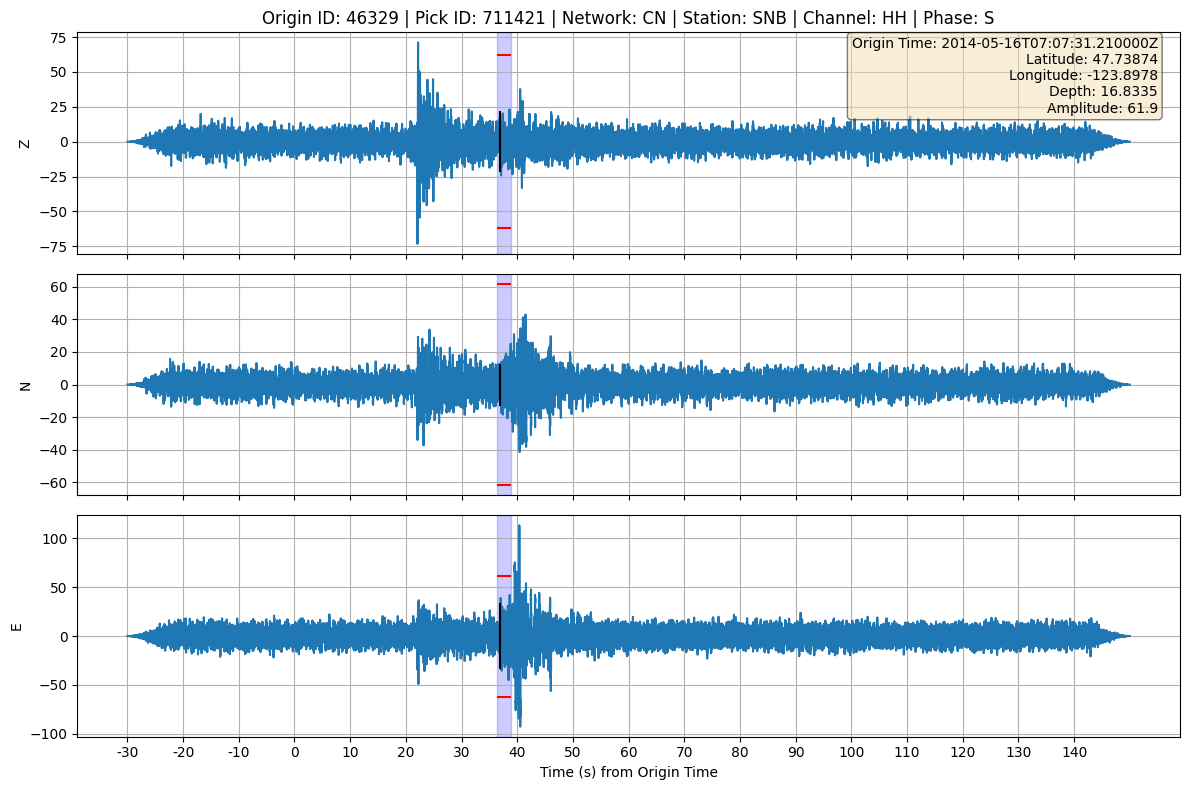

PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


<Figure size 640x480 with 0 Axes>

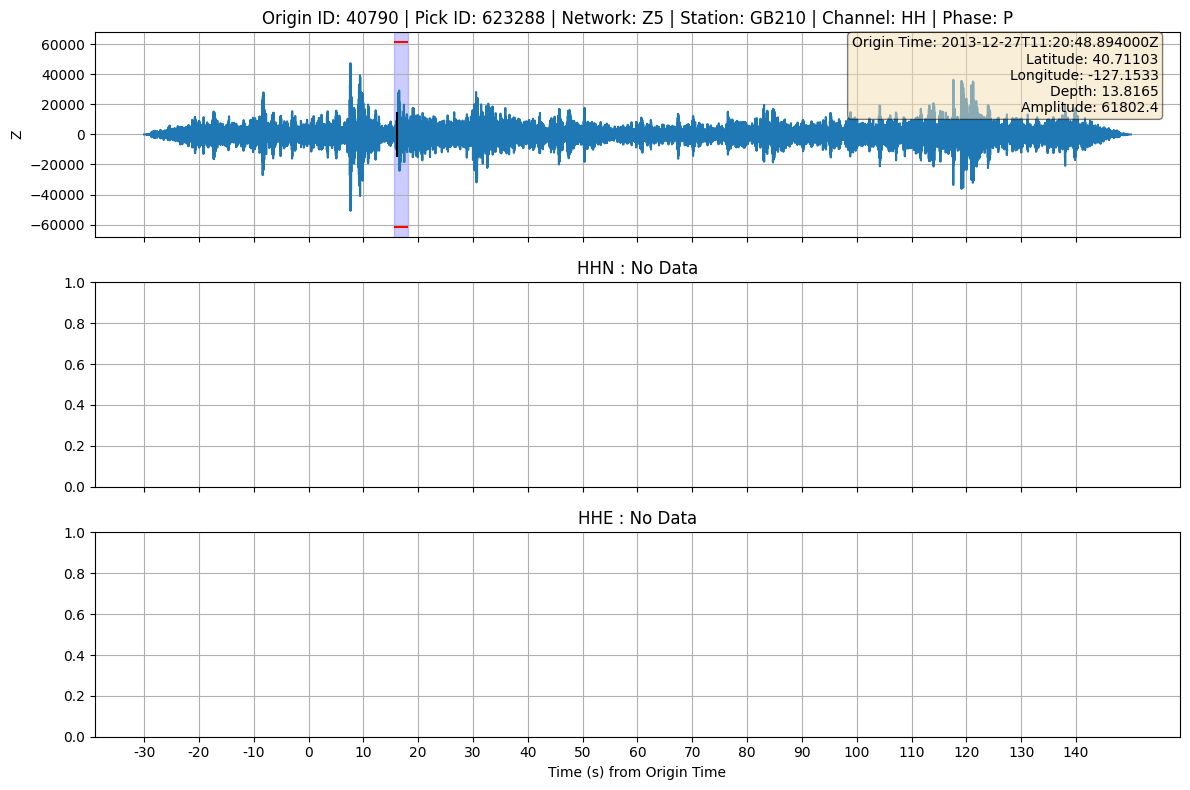

PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


<Figure size 640x480 with 0 Axes>

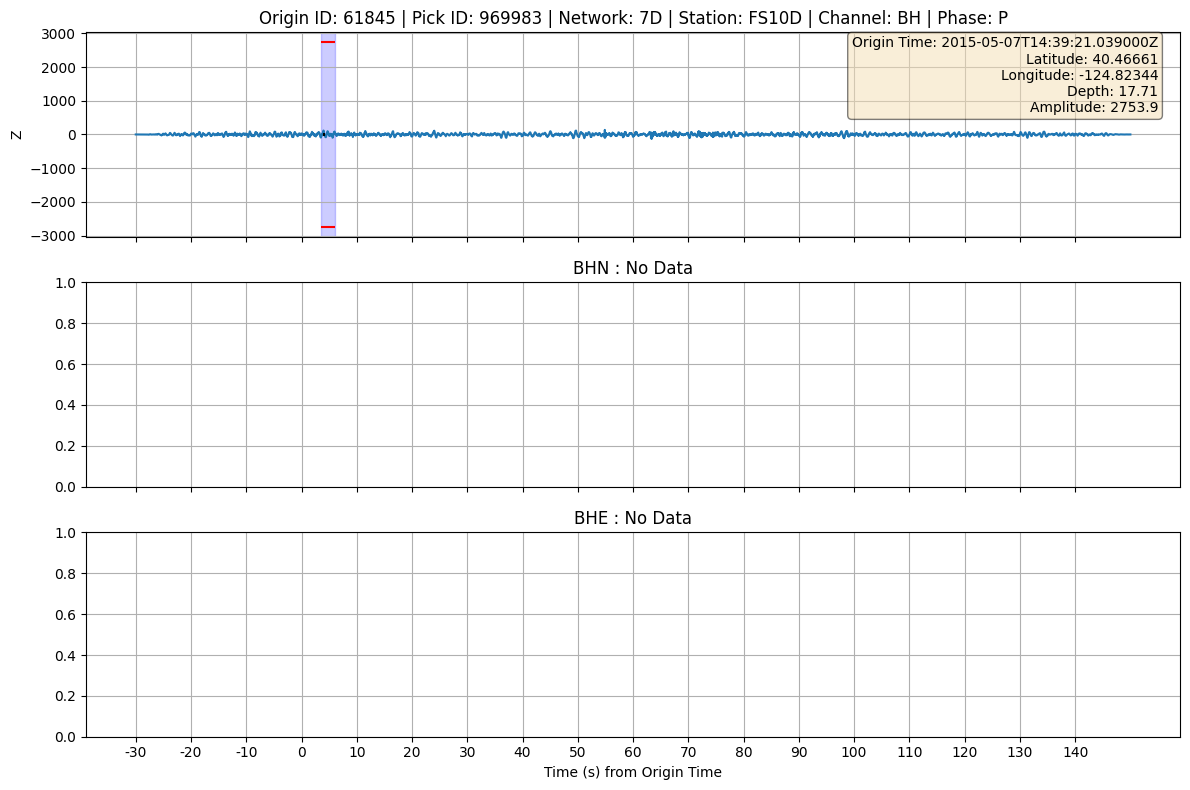

PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


<Figure size 640x480 with 0 Axes>

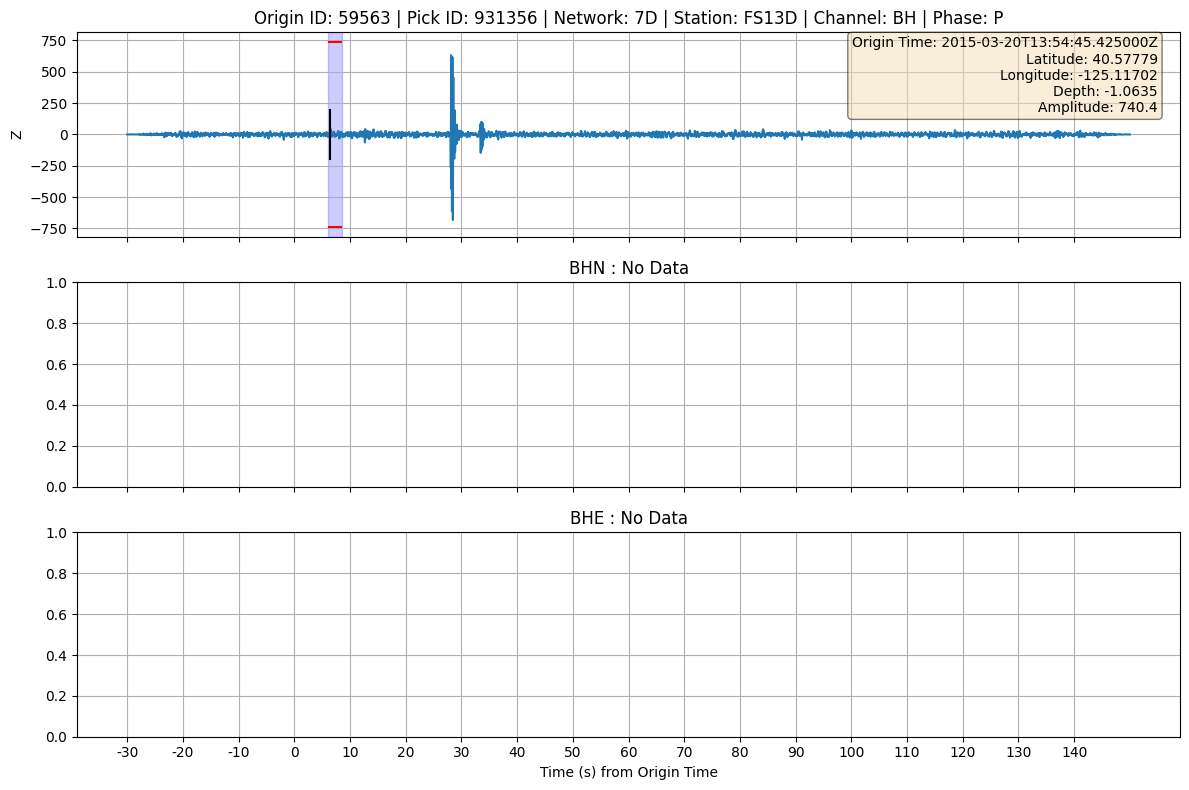

PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


<Figure size 640x480 with 0 Axes>

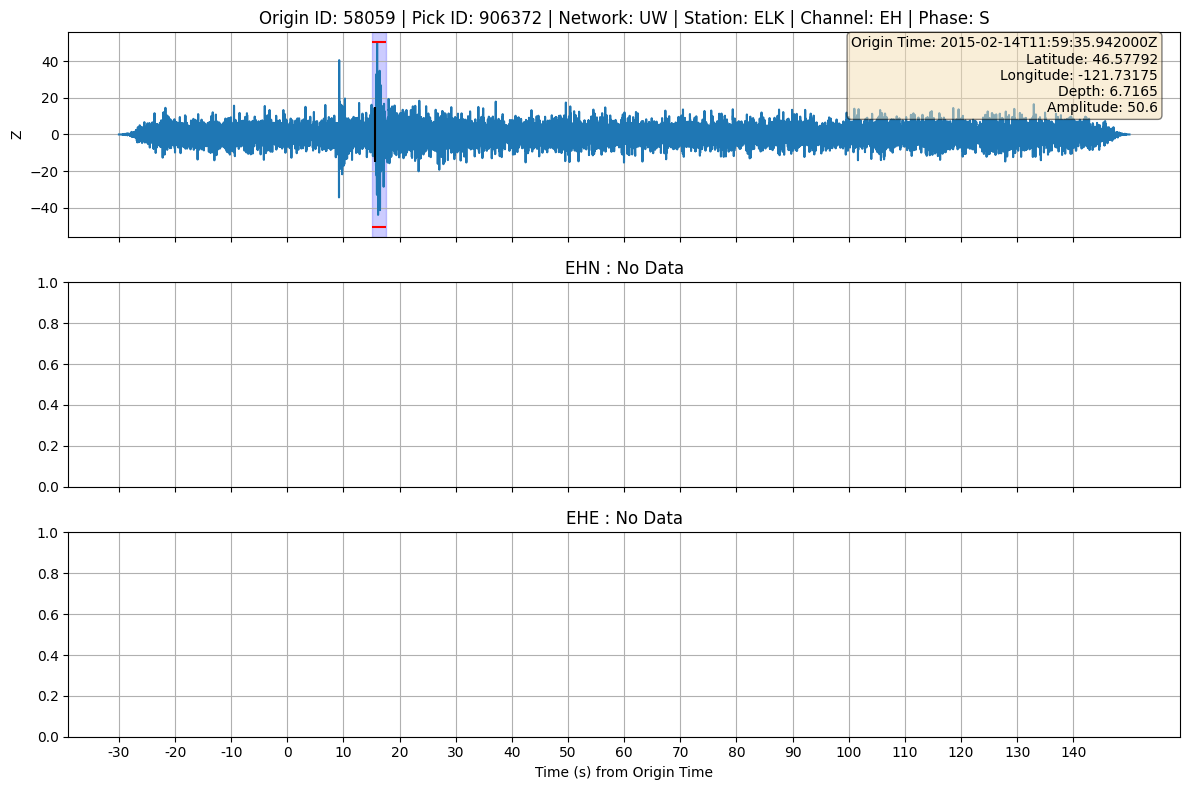

PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


<Figure size 640x480 with 0 Axes>

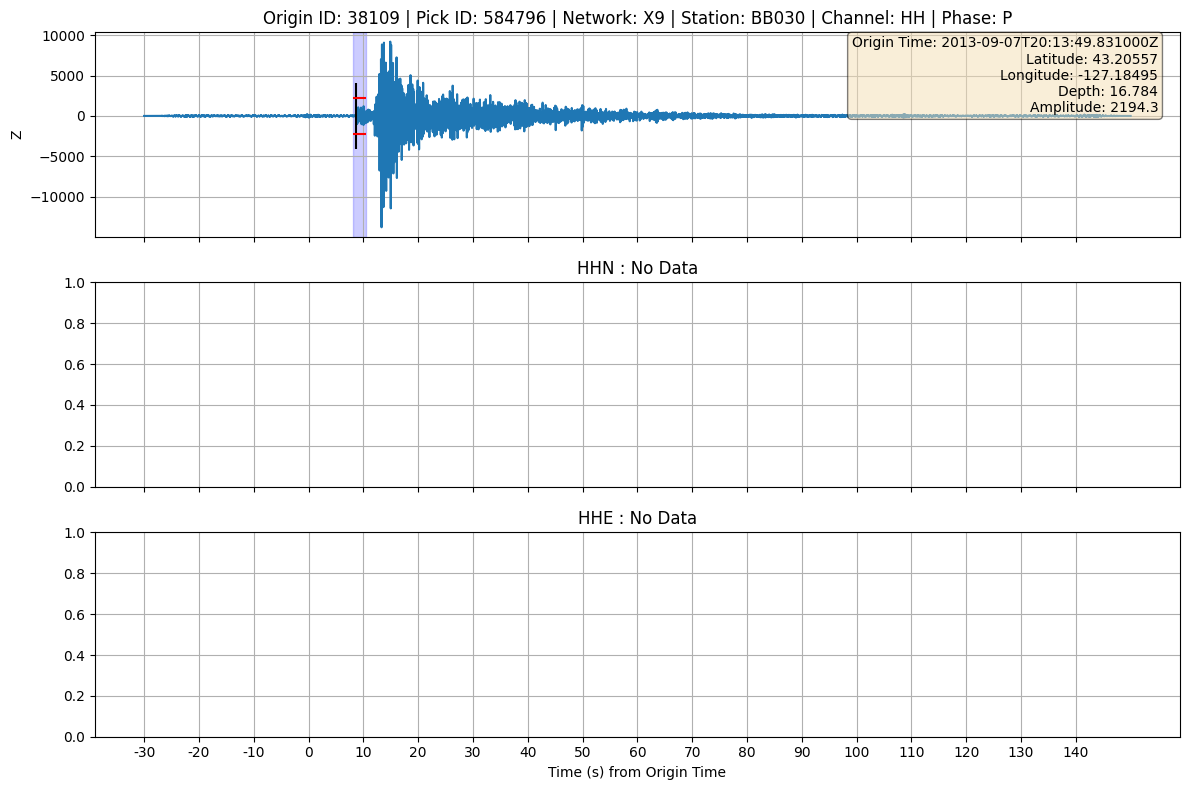

PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


<Figure size 640x480 with 0 Axes>

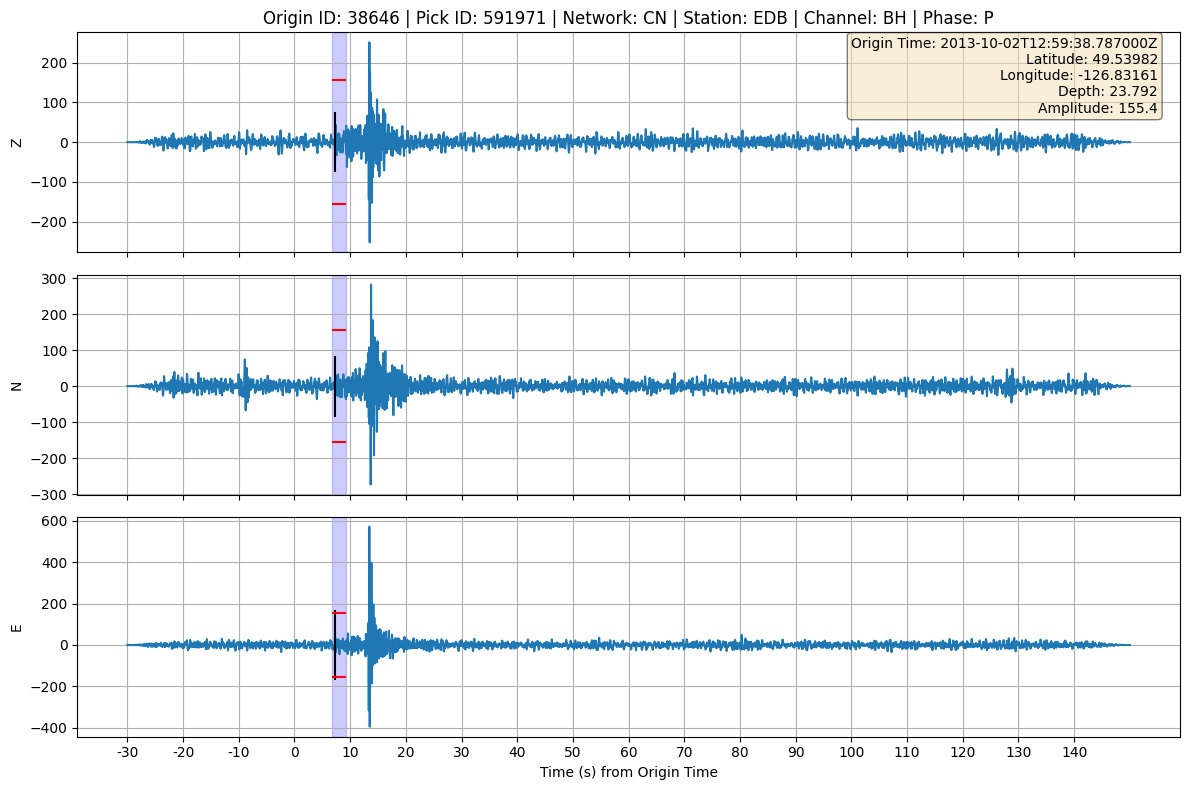

<Figure size 640x480 with 0 Axes>

In [32]:
plot_waveforms_for_picks(df, dir_plots, window_before, window_after, window_amp_calc_before, window_amp_calc_after, n_picks, source, scaling_factor_vline)

backup

In [ ]:
# # Function to plot waveforms using Obspy bulk request
 
# def plot_waveforms_for_picks(assigned_picks_df, dir_plots, window_before=30, window_after=120, window_amp_calc_before = 0.5, window_amp_calc_after = 2, n_picks=100, source='pnwstore', scaling_factor_vline=0.1):
     
#     # Prepare the lists
#     bulk = []
#     pick_info = []
#     # ls_idx = np.random.choice(a=len(assigned_picks_df), size=(n_picks))
#     ls_idx = np.arange(n_picks)
    
#     # for i, row in assigned_picks_df.head(n_picks).iterrows():
#     for i in range(len(ls_idx)):
#         orid = assigned_picks_df.iloc[ls_idx[i]]['idx']
#         pick_id = assigned_picks_df.iloc[ls_idx[i]]['arid']
      
#         date, _time = assigned_picks_df.iloc[ls_idx[i]]['time'].split(' ')
#         datetime_str = date+'T'+_time
#         origin_time = UTCDateTime(datetime_str)  # Accept ISO string directly
#         latitude = assigned_picks_df.iloc[ls_idx[i]]['latitude']
#         longitude = assigned_picks_df.iloc[ls_idx[i]]['longitude']
#         depth = assigned_picks_df.iloc[ls_idx[i]]['depth']
        
#         # You may need to adjust these fields to match your DataFrame columns
#         network = assigned_picks_df.iloc[ls_idx[i]]['station'].split('.')[0].strip()
#         station = assigned_picks_df.iloc[ls_idx[i]]['station'].split('.')[1].strip()
#         channel = "*H*"
#         starttime = origin_time - window_before 
#         endtime = origin_time + window_after
#         time_pick = assigned_picks_df.iloc[ls_idx[i]]['time_pick']
#         time_pick_origin  = UTCDateTime(assigned_picks_df.iloc[ls_idx[i]]['time_pick']) - origin_time
#         phase = assigned_picks_df.iloc[ls_idx[i]]['phase']
#         amp = assigned_picks_df.iloc[ls_idx[i]]['Amplitude']

#         bulk.append((network, station, channel, starttime, endtime))
#         pick_info.append({
#             'orid': orid,
#             'pick_id': pick_id,
#             'origin_time': origin_time,
#             'latitude': latitude,
#             'longitude': longitude,
#             'depth': depth,
#             'network': network,
#             'station': station,
#             'channel': channel,
#             'starttime': starttime,
#             'endtime': endtime,
#             'time_pick': time_pick,
#             'time_pick_origin': time_pick_origin,
#             'phase': phase,
#             'amp': amp
#         })


#     # Parameters to process waveforms
#     new_sampling_rate = 100 # in Hz
#     # freqmax = 15 # in Hz
#     # freqmin = 4 # in Hz
#     freq_highpass = 2 # in Hz


#     # Plotting
#     for i, info in enumerate(pick_info):

#         network = pick_info[i]['network']
#         station = pick_info[i]['station']
#         channel = pick_info[i]['channel']
#         starttime = pick_info[i]['starttime']
#         endtime = pick_info[i]['endtime']
#         amp = pick_info[i]['amp']

#         time_pick = pick_info[i]['time_pick']
#         time_pick_origin = pick_info[i]['time_pick_origin']

#         fname = dir_plots+f"/{network}_{station}_arid_{info['pick_id']}.png"

#         time.sleep(0.1)

#         try:
#             st = get_waveforms(
#                 network=network,
#                 station=station,
#                 channel=channel,
#                 starttime=starttime,
#                 endtime=endtime,
#                 source=source
#             )
#         except Exception as e:
#             print(f"Request failed: {e}")
#             st = Stream()

#         time.sleep(0.1)

#         # ---------------------------------------------------------
#         # Select preferred channel family
#         # ---------------------------------------------------------

#         has_HH = bool(st.select(id=f'{network}.{station}..HH?'))
#         has_BH = bool(st.select(id=f'{network}.{station}..BH?'))
#         has_EH = bool(st.select(id=f'{network}.{station}..EH?'))

#         sdata = Stream()

#         if has_HH:
#             sdata += st.select(id=f'{network}.{station}..HH*')
#             channel_prefix = "HH"

#         elif has_BH:
#             sdata += st.select(id=f'{network}.{station}..BH*')
#             channel_prefix = "BH"

#         elif has_EH:
#             sdata += st.select(id=f'{network}.{station}..EH*')
#             channel_prefix = "EH"

#         else:
#             print(f'No HH, BH, or EH data available at {network}.{station} at {time_pick}. Skipping.')
#             continue

#         # ---------------------------------------------------------
#         # Create figure with 3 components
#         # ---------------------------------------------------------

#         fig, axes = plt.subplots(
#             3,
#             1,
#             figsize=(12, 8),
#             sharex=True
#         )

#         component_list = ['Z', 'N', 'E']

#         for ax, comp in zip(axes, component_list):

#             tr_select = sdata.select(channel=f"{channel_prefix}{comp}")

#             # -----------------------------------------------------
#             # Leave blank if component does not exist
#             # -----------------------------------------------------

#             if len(tr_select) == 0:

#                 ax.set_title(f"{channel_prefix}{comp} : No Data")
#                 ax.grid()

#                 continue

#             tr = tr_select[0].copy()

#             # -----------------------------------------------------
#             # Process waveform
#             # -----------------------------------------------------

#             tr.resample(new_sampling_rate)

#             tr.detrend(type='demean')
#             tr.taper(max_percentage=0.05)
#             tr.filter(type='highpass', freq=freq_highpass)

#             data = tr.data

#             times = np.linspace(
#                 -window_before,
#                 window_after,
#                 tr.stats.npts
#             )

#             time_vline = time_pick_origin

#             ymax = np.max(np.abs(data)) * scaling_factor_vline
#             ymin = -np.max(np.abs(data)) * scaling_factor_vline

#             xmax = time_vline + window_amp_calc_after
#             xmin = time_vline - window_amp_calc_before

#             # -----------------------------------------------------
#             # Plot waveform
#             # -----------------------------------------------------

#             ax.axvspan(
#                 xmin,
#                 xmax,
#                 color='b',
#                 alpha=0.2
#             )

#             ax.plot(times, data)

#             ax.vlines(
#                 time_vline,
#                 ymin,
#                 ymax,
#                 color='k',
#                 linestyles='solid'
#             )

#             ax.hlines(
#                 amp,
#                 xmax=xmax,
#                 xmin=xmin,
#                 color='r'
#             )

#             ax.hlines(
#                 -amp,
#                 xmax=xmax,
#                 xmin=xmin,
#                 color='r'
#             )

#             ax.set_ylabel(comp)
#             ax.grid()

#         # ---------------------------------------------------------
#         # Common formatting
#         # ---------------------------------------------------------

#         axes[0].set_title(
#             f"Origin ID: {info['orid']} | "
#             f"Pick ID: {info['pick_id']} | "
#             f"Network: {info['network']} | "
#             f"Station: {info['station']} | "
#             f"Channel: {channel_prefix} | "
#             f"Phase: {info['phase']}"
#         )

#         axes[-1].set_xlabel("Time (s) from Origin Time")

#         ticks = np.arange(-window_before, window_after, 10)
#         str_ticks = [str(t) for t in ticks]

#         axes[-1].set_xticks(ticks=ticks, labels=str_ticks)

#         # Event information box
#         info_text = (
#             f"Origin Time: {info['origin_time']}\n"
#             f"Latitude: {info['latitude']}\n"
#             f"Longitude: {info['longitude']}\n"
#             f"Depth: {info['depth']}\n"
#             f"Amplitude: {np.round(amp, decimals=1)}"
#         )

#         props = dict(
#             boxstyle='round',
#             facecolor='wheat',
#             alpha=0.5
#         )

#         axes[0].text(
#             0.98,
#             0.98,
#             info_text,
#             transform=axes[0].transAxes,
#             fontsize=10,
#             verticalalignment='top',
#             horizontalalignment='right',
#             bbox=props
#         )

#         plt.tight_layout()
#         plt.show()
#         plt.savefig(fname=fname, format='png')
#         plt.close(fig)

#         time.sleep(0.1)

